### **Pergunta 1: O turismo cresceu ou encolheu na última década?**

In [274]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binomtest
import scipy.stats as stats

In [275]:
df = pd.read_csv('Tourism Quantity Data.csv')

### 1. Relatório dos dados

#### 1.1 Análise temporal

In [276]:
# Criando métricas
df['Receipts_per_Arrival'] = df['Receipts'] / df['Arrivals']
df['Tourism_Balance'] = df['Receipts'] - df['Expenditures']

# tratando divisões por nulos
df = df.replace([np.inf, -np.inf], np.nan)

df_temporal = df.groupby('Ano').agg({
    'Arrivals': 'sum',               # soma mundial
    'Receipts': 'sum',               # soma mundial
    'Expenditures': 'sum',           # soma mundial
    'Receipts_per_Arrival': 'mean',  # média mundial
    'Tourism_Balance': 'mean'        # média mundial
}).reset_index()

variables = ['Arrivals', 'Receipts', 'Expenditures', 'Receipts_per_Arrival', 'Tourism_Balance']
df_stats_pandas = df_temporal[variables].agg(['mean', 'median', 'std', 'var']).T
df_stats_pandas.columns = ['Média', 'Mediana', 'Desvio Padrão', 'Variância']

# calculando crescimento das variveis (ultimo ano - primeiro ano)
valor_inicial = df_temporal[variables].iloc[0]
valor_final = df_temporal[variables].iloc[-1]
crescimento_acumulado = ((valor_final - valor_inicial) / valor_inicial) * 100

df_stats_pandas['Crescimento Acumulado (%)'] = crescimento_acumulado

colunas_ordenadas = ['Crescimento Acumulado (%)', 'Média', 'Mediana', 'Desvio Padrão']
#colunas_ordenadas = ['Crescimento Acumulado (%)', 'Média', 'Mediana', 'Desvio Padrão', 'Variância']
df_stats_pandas = df_stats_pandas[colunas_ordenadas]

pd.set_option('display.float_format', lambda x: '%.2f' % x)
df_stats_pandas['Crescimento Acumulado (%)'] = df_stats_pandas['Crescimento Acumulado (%)'].map('{:.2f}%'.format)

#print(df_stats_pandas)
df_formatado = df_stats_pandas.copy()

# dividindo os valores gigantes por 1 Bilhão (1e9) para facilitar a leitura
colunas_bilhoes = ['Arrivals', 'Receipts', 'Expenditures', 'Tourism_Balance']

for col in ['Média', 'Mediana', 'Desvio Padrão']:
    df_formatado.loc[colunas_bilhoes, col] = df_formatado.loc[colunas_bilhoes, col] / 1e9

# Formatamos a tabela para mostrar o texto " Bilhões" onde aplicável
pd.set_option('display.float_format', lambda x: f"{x:,.2f}")

print("========================== TABELA DE ESTATISTICAS ==========================")
print("(Valores absolutos em Bilhões US$, exceto Receipts_per_Arrival)")
print(df_formatado)

========================== TABELA DE ESTATISTICAS ==========================
(Valores absolutos em Bilhões US$, exceto Receipts_per_Arrival)
                     Crescimento Acumulado (%)  Média  Mediana  Desvio Padrão
Arrivals                                52.76%   1.71     1.63           0.22
Receipts                               116.38% 937.86   918.43         227.85
Expenditures                            80.77% 814.36   837.77         144.29
Receipts_per_Arrival                    31.79% 964.60   988.59          85.39
Tourism_Balance                        853.23%   0.83     0.51           0.61


Ao longo do período analisado, o turismo global cresceu de forma consistente, mas o mais interessante não foi só o aumento no número de viagens. As chegadas internacionais subiram cerca de 52,8%, enquanto a receita gerada pelo setor mais que dobrou, com alta de 116,4%. Isso indica que o turismo passou a gerar muito mais valor por visitante.

Na prática, o turista médio passou a gastar mais em cada viagem, com um aumento de aproximadamente 31,8%, chegando a cerca de US$ 964,60. Ao mesmo tempo, as despesas globais cresceram, mas em um ritmo menor (80,8%), o que ajudou a melhorar o resultado geral do setor.

Com isso, o saldo do turismo teve um crescimento muito forte, de mais de 850%, mostrando que o setor não só se expandiu em quantidade, mas também se tornou mais eficiente em gerar e reter recursos financeiros.

##### Preparação dos dados

In [277]:
sns.set_theme(style="whitegrid")
plt.rcParams['axes.titleweight'] = 'bold'
anos = df_temporal['Ano'].unique()
variables = ['Arrivals', 'Receipts', 'Expenditures', 'Receipts_per_Arrival', 'Tourism_Balance']
colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd']

# Criando variaçoes anuais
df_growth = df_temporal.copy()
for col in variables:
    df_growth[f'{col}_Anual_Var'] = df_growth[col].pct_change() * 100

# criando tabela indexada em ano 1 =100
df_indexed = df_temporal.copy()
for col in variables:
    base_value = df_indexed[col].iloc[0]
    df_indexed[col] = (df_indexed[col] / base_value) * 100

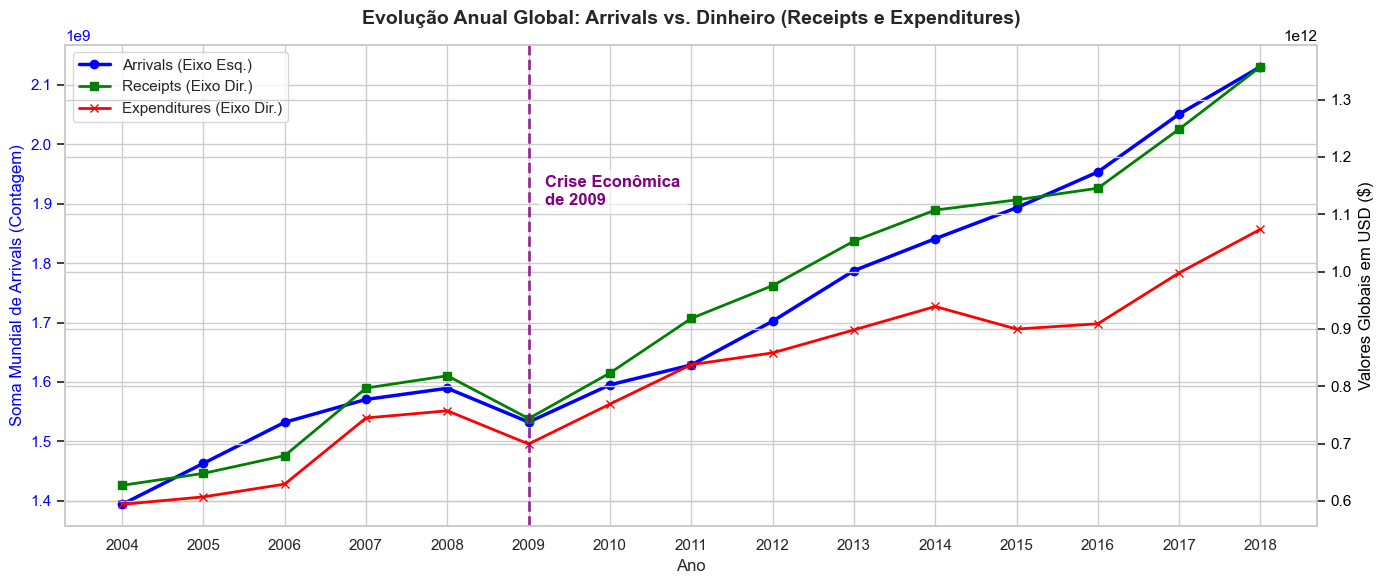

In [278]:
# Evolução absoluta anual
fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = 'blue'
ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('Soma Mundial de Arrivals (Contagem)', color=color1)
line1 = ax1.plot(df_temporal['Ano'], df_temporal['Arrivals'], color=color1, marker='o', linewidth=2.5, label='Arrivals (Eixo Esq.)')
ax1.tick_params(axis='y', labelcolor=color1)

# Criando o segundo eixo (direito) para os valores financeiros em USD
ax2 = ax1.twinx()  
color2 = 'green'
color3 = 'red'
ax2.set_ylabel('Valores Globais em USD ($)', color='black')
line2 = ax2.plot(df_temporal['Ano'], df_temporal['Receipts'], color=color2, marker='s', linewidth=2, label='Receipts (Eixo Dir.)')
line3 = ax2.plot(df_temporal['Ano'], df_temporal['Expenditures'], color=color3, marker='x', linewidth=2, label='Expenditures (Eixo Dir.)')
ax2.tick_params(axis='y', labelcolor='black')

#Crise de 2009
if 2009 in anos:
    plt.axvline(x=2009, color='purple', linestyle='--', alpha=0.8, linewidth=2)
    ax2.text(2009.2, ax2.get_ylim()[1]*0.8, 'Crise Econômica\nde 2009', color='purple', weight='bold', bbox=dict(facecolor='white', alpha=0.6))

# unindo legendas de arrival e receitas/chegadas
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Evolução Anual Global: Arrivals vs. Dinheiro (Receipts e Expenditures)', fontsize=14, pad=15)
ax1.set_xticks(anos)
plt.tight_layout()
plt.show()

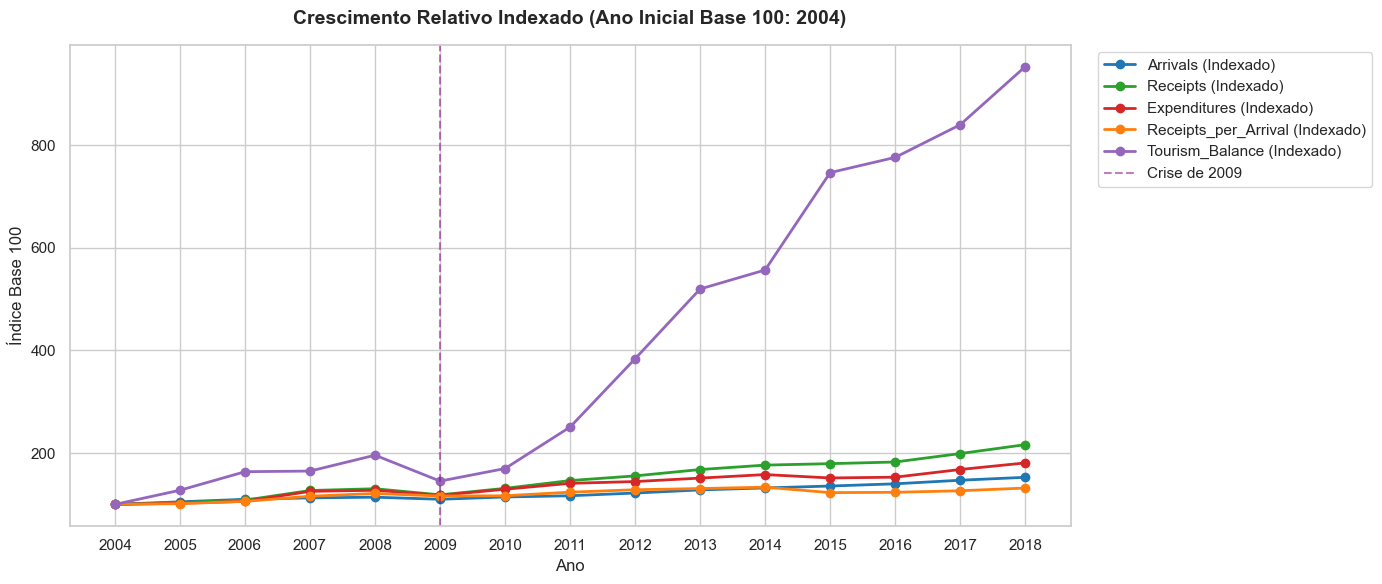

In [279]:
#Crescimento relativo de com base 100
plt.figure(figsize=(14, 6))

for col, color in zip(variables, colors):
    plt.plot(df_indexed['Ano'], df_indexed[col], marker='o', linewidth=2, color=color, label=f'{col} (Indexado)')

if 2009 in anos:
    plt.axvline(x=2009, color='purple', linestyle='--', alpha=0.5, label='Crise de 2009')

plt.title(f'Crescimento Relativo Indexado (Ano Inicial Base 100: {int(anos[0])})', fontsize=14, pad=15)
plt.xlabel('Ano')
plt.ylabel('Índice Base 100')
plt.xticks(anos)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

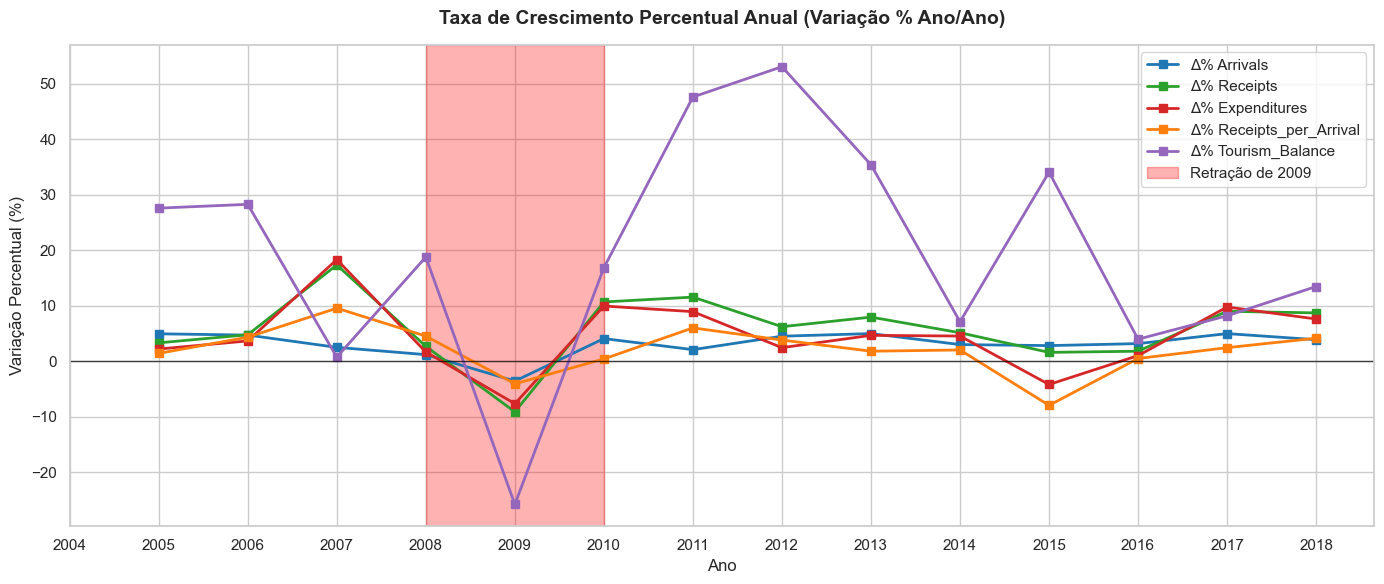

In [280]:
# Variacao anual
plt.figure(figsize=(14, 6))

for col, color in zip(variables, colors):
    # O primeiro ano ficará nulo (NaN), então o iloc[1:] pula ele no plot
    plt.plot(df_growth['Ano'].iloc[1:], df_growth[f'{col}_Anual_Var'].iloc[1:], marker='s', linewidth=2, color=color, label=f'Δ% {col}')

plt.axhline(0, color='black', linestyle='-', alpha=0.7, linewidth=1)

# Destaque entre 2008 e 2010
if 2009 in anos:
    plt.axvspan(2008, 2010, color='red', alpha=0.3, label='Retração de 2009')

plt.title('Taxa de Crescimento Percentual Anual (Variação % Ano/Ano)', fontsize=14, pad=15)
plt.xlabel('Ano')
plt.ylabel('Variação Percentual (%)')
plt.xticks(anos)

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

*Obs: em 2015 houve uma variação negativa de receitas na base imputada*

Entre 2004 e 2018, o turismo global teve um crescimento forte e praticamente contínuo, interrompido apenas pela crise de 2009. Nesse ano, todos os indicadores caíram de forma significativa. Apesar disso, a recuperação foi rápida: já em 2010, o setor voltou a crescer com força e manteve uma trajetória positiva até o fim da série.

No período pós-crise, o destaque foi a mudança de escala na lucratividade. O número de viajantes cresceu de forma constante, mas a receita aumentou bem mais rápido, indicando maior valor gerado por turista. Isso fez com que o saldo do turismo se destacasse ainda mais, chegando a crescer quase dez vezes ao longo da década, mostrando um setor mais eficiente e cada vez mais voltado à geração de receita.

#### 1.2. Variação, ruído e volatibilidade

In [281]:
# Variáveis analisadas
vars = ['Arrivals', 'Receipts', 'Expenditures', 'Receipts_per_Arrival', 'Tourism_Balance']

df_var = df_temporal.copy()

# Calculando Variação Anual (%) e Média Móvel (3 anos) para todas as variáveis
for col in vars:
    df_var[f'{col}_Var%'] = df_var[col].pct_change() * 100
    df_var[f'{col}_MM3'] = df_var[col].rolling(window=3).mean()

In [282]:
cols_var = [f'{col}_Var%' for col in vars]

# Volatilidade Global (Desvio Padrão e Variância)
vol_global = df_var[cols_var].agg(['std', 'var']).T
vol_global.columns = ['Desvio Padrão', 'Variância']
print("================ Volatilidade Global ==================\n \
Quanto maior o desvio padrão, mais instavel a váriavel")
print(vol_global.round(2))

# Top 3 Maiores Quedas e Altas (Baseado nas Receitas)
print("\n========= Maiores Quedas (Receitas) ============")
print(df_var[['Ano', 'Receipts_Var%']].sort_values('Receipts_Var%').head(3))

print("\n========= Maiores Crescimentos (Receitas) ==========")
print(df_var[['Ano', 'Receipts_Var%']].sort_values('Receipts_Var%', ascending=False).head(3))

================ Volatilidade Global ==================
 Quanto maior o desvio padrão, mais instavel a váriavel
                           Desvio Padrão  Variância
Arrivals_Var%                       2.26       5.11
Receipts_Var%                       6.12      37.51
Expenditures_Var%                   6.40      40.90
Receipts_per_Arrival_Var%           4.24      18.00
Tourism_Balance_Var%               20.56     422.85

========= Maiores Quedas (Receitas) ============
     Ano  Receipts_Var%
5   2009          -9.12
11  2015           1.60
12  2016           1.81

========= Maiores Crescimentos (Receitas) ==========
    Ano  Receipts_Var%
3  2007          17.35
7  2011          11.56
6  2010          10.69


obs: base imputada obteve os mesmos anos, mas com variação menor.

In [283]:
df_pais = df.sort_values(['País', 'Ano']).copy()

df_pais['Var_Anual_%'] = df_pais.groupby('País')['Receipts'].pct_change() * 100

# Volatilidade = Desvio Padrão dessa variação
vol_pais = df_pais.groupby('País')['Var_Anual_%'].std().reset_index()

print("--- Top 10 Países Mais Voláteis usando desvio padrão ---")
print(vol_pais.sort_values('Var_Anual_%', ascending=False).head(10))

--- Top 10 Países Mais Voláteis usando desvio padrão ---
                             País  Var_Anual_%
42   Democratic Republic of Congo     1,413.59
95               Marshall Islands       517.25
63                         Guinea       280.69
116              Papua New Guinea       234.94
147                    Tajikistan       166.59
142                         Sudan       144.48
64                  Guinea-Bissau       142.27
136               Solomon Islands       100.73
50                       Eswatini        97.66
114                     Palestine        88.92


C:\Users\marco\AppData\Local\Temp\ipykernel_29204\265129283.py:3: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_pais['Var_Anual_%'] = df_pais.groupby('País')['Receipts'].pct_change() * 100


C:\Users\marco\AppData\Local\Temp\ipykernel_29204\1198786275.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Variável', y='Variação Anual (%)', data=df_box, palette='Set2')


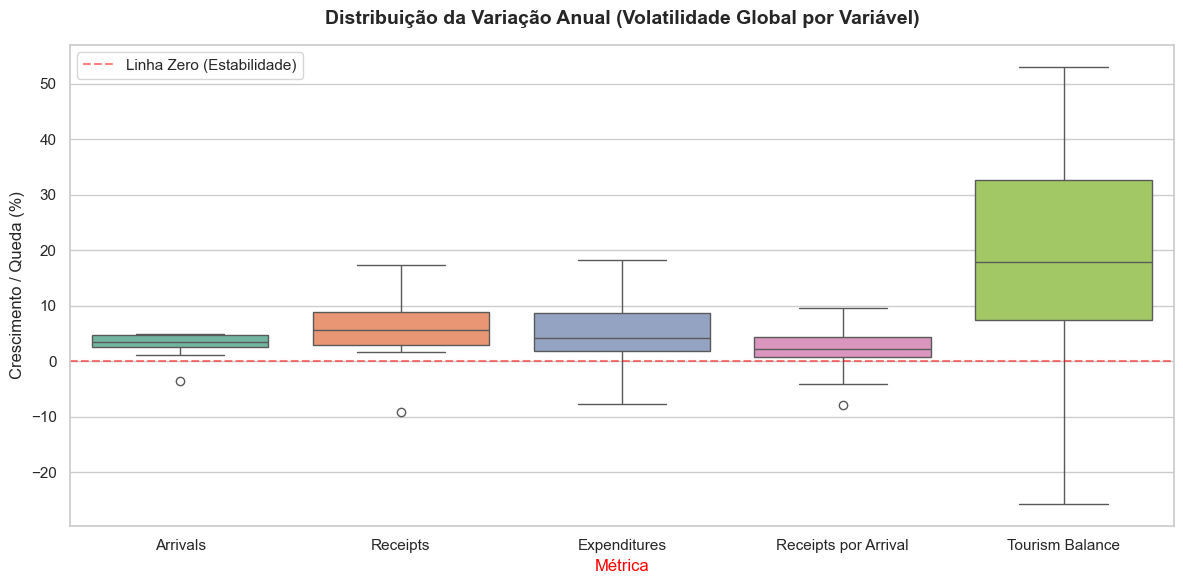

In [284]:
# Boxplot da variação anual
plt.figure(figsize=(12, 6))
df_box = df_var.melt(id_vars='Ano', value_vars=cols_var, var_name='Variável', value_name='Variação Anual (%)') # Tranformando colunas em linhas para boxplot

sns.boxplot(x='Variável', y='Variação Anual (%)', data=df_box, palette='Set2')
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Linha Zero (Estabilidade)')
plt.title('Distribuição da Variação Anual (Volatilidade Global por Variável)', fontsize=14, pad=15)
plt.ylabel('Crescimento / Queda (%)')
plt.xlabel('Métrica')
plt.xticks(ticks=range(5), labels=['Arrivals', 'Receipts', 'Expenditures', 'Receipts por Arrival', 'Tourism Balance'])
plt.legend()
plt.tight_layout()
plt.show()

*obs: Nos dados imputados, temos o dobro de outliers e as caudas são maiores.*

Podemos ver métricas que variam muito como expenditures e tourism balance, e outras que oscilam pouco, como receipts por arrival e arrivals. Os outliers inferiores que aparecem em 3 métricas se devem as variações da crise de 2008.

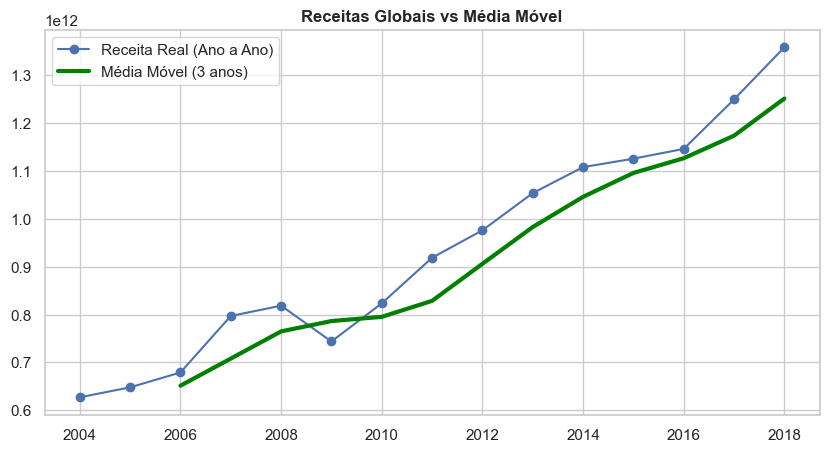

In [285]:
plt.figure(figsize=(10, 5))

plt.plot(df_var['Ano'], df_var['Receipts'], marker='o', label='Receita Real (Ano a Ano)', alpha=1)
plt.plot(df_var['Ano'], df_var['Receipts_MM3'], color='green', linewidth=3, label='Média Móvel (3 anos)')

plt.title('Receitas Globais vs Média Móvel')
plt.legend()
plt.show()

Com essa média movel (media dos 2 anos anteriores + ano atual), podemos observar que a receita apresenta um ritmo de crescimento quase linear ao longo do período analisado. 

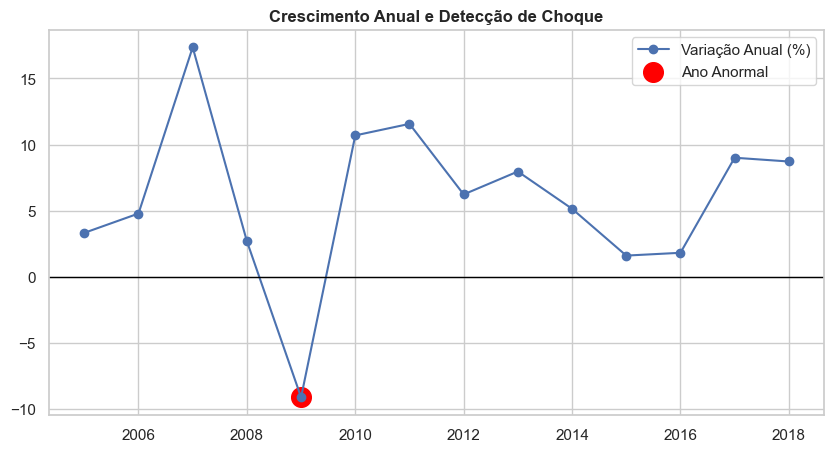

In [286]:
plt.figure(figsize=(10, 5))

# Variação normal
plt.plot(df_var['Ano'], df_var['Receipts_Var%'], marker='o', label='Variação Anual (%)')

# Identificando o pior ano
ano_anormal = df_var.loc[df_var['Receipts_Var%'].idxmin()]

# Marcador vermelho no ano anormal
plt.scatter(ano_anormal['Ano'], ano_anormal['Receipts_Var%'], color='red', s=200, label='Ano Anormal')
plt.axhline(0, color='black', linewidth=1)

plt.title('Crescimento Anual e Detecção de Choque')
plt.legend()
plt.show()

Como esperado o ano com maior choque negativo da receita ocorreu em 2009

Os resultados indicam que, em determinados anos, houve uma grande volatilidade nas variáveis estudadas, resultado de eventos históricos, crises econômicas, mudanças geopolíticas e outros fatores que impactaram o setor de turismo. Apesar dessas variações e do período de declínio observado, os dados apontam para uma notável capacidade de recuperação ao longo do tempo. No geral, as métricas globais seguem uma tendência de crescimento constante, indicando uma expansão gradual da atividade turística no mundo, mesmo com interferências.

#### 1.3. Testes de hipótese sobre crescimento

Para avaliar o crescimento global do setor turístico, foi considerada como hipótese nula *(H0)* que a proporção de países com crescimento positivo seria menor ou igual a 50% *(p≤0,5)*.

In [295]:
df_copy = df.copy()
df_copy['Receipts_per_Arrival'] = df_copy['Receipts'] / df_copy['Arrivals']
df_copy['Tourism_Balance'] = df_copy['Receipts'] - df_copy['Expenditures']

# Tratar valores ou nulos gerados pela divisão
df_copy = df_copy.replace([np.inf, -np.inf], np.nan)

#encontra o primeiro e o último ano de cada país para calcular o crescimento real
variaveis = ['Arrivals', 'Receipts', 'Expenditures', 'Receipts_per_Arrival', 'Tourism_Balance']
resultados_finais = []

# Agrupando por país para pegar o primeiro ano (2004) e o último (2018) disponíveis
for var in variaveis:
    # Filtrando apenas linhas que possuem a variável preenchida
    df_var = df_copy.dropna(subset=[var])
    
    # Pegando o ano mínimo e máximo de cada país
    anos = df_var.groupby('País')['Ano'].agg(['min', 'max']).reset_index()
    
    paises_cresceram = 0
    paises_cairam = 0
    total_paises = 0
    
    for _, row in anos.iterrows():
        pais = row['País']
        ano_ini = row['min']
        ano_fim = row['max']
        
        # Ignora se o país só tiver 1 ano de dado
        if ano_ini == ano_fim:
            continue
            
        val_ini = df_var[(df_var['País'] == pais) & (df_var['Ano'] == ano_ini)][var].values[0]
        val_fim = df_var[(df_var['País'] == pais) & (df_var['Ano'] == ano_fim)][var].values[0]
        
        # Verifica se cresceu ou caiu
        if val_fim > val_ini:
            paises_cresceram += 1
            total_paises += 1
        elif val_fim < val_ini:
            paises_cairam += 1
            total_paises += 1
            
    # Execução do Teste Binomial Unicaudal (Alternativa: maior que 0.5)
    # H0: p <= 0.5 | H1: p > 0.5
    resultado_teste = binomtest(paises_cresceram, n=total_paises, p=0.5, alternative='greater')
    p_valor = resultado_teste.pvalue
    
    # Guardando os resultados detalhados
    resultados_finais.append({
        'Variável': var,
        'Total Países (N)': total_paises,
        'Qtd Crescimento (+)': paises_cresceram,
        'Prop Crescimento (+)': f"{(paises_cresceram / total_paises)*100:.2f}%",
        'Qtd Queda (-)': paises_cairam,
        'Prop Queda (-)': f"{(paises_cairam / total_paises)*100:.2f}%",
        'P-Valor': f"{p_valor:.4e}",
        'Rejeita H0?': 'Sim' if p_valor < 0.05 else 'Não'
    })

df_relatorio = pd.DataFrame(resultados_finais)
print(df_relatorio.to_string(index=False))

            Variável  Total Países (N)  Qtd Crescimento (+) Prop Crescimento (+)  Qtd Queda (-) Prop Queda (-)    P-Valor Rejeita H0?
            Arrivals               166                  154               92.77%             12          7.23% 7.0454e-33         Sim
            Receipts               160                  149               93.12%             11          6.88% 2.2883e-32         Sim
        Expenditures               161                  147               91.30%             14          8.70% 1.9032e-29         Sim
Receipts_per_Arrival               160                   97               60.62%             63         39.38% 4.4368e-03         Sim
     Tourism_Balance               158                   99               62.66%             59         37.34% 9.1318e-04         Sim


Abaixo podemos ver como exemplo uma distribuição normal plotada sobre a H0 das chegadas e o P-valor correspondente:

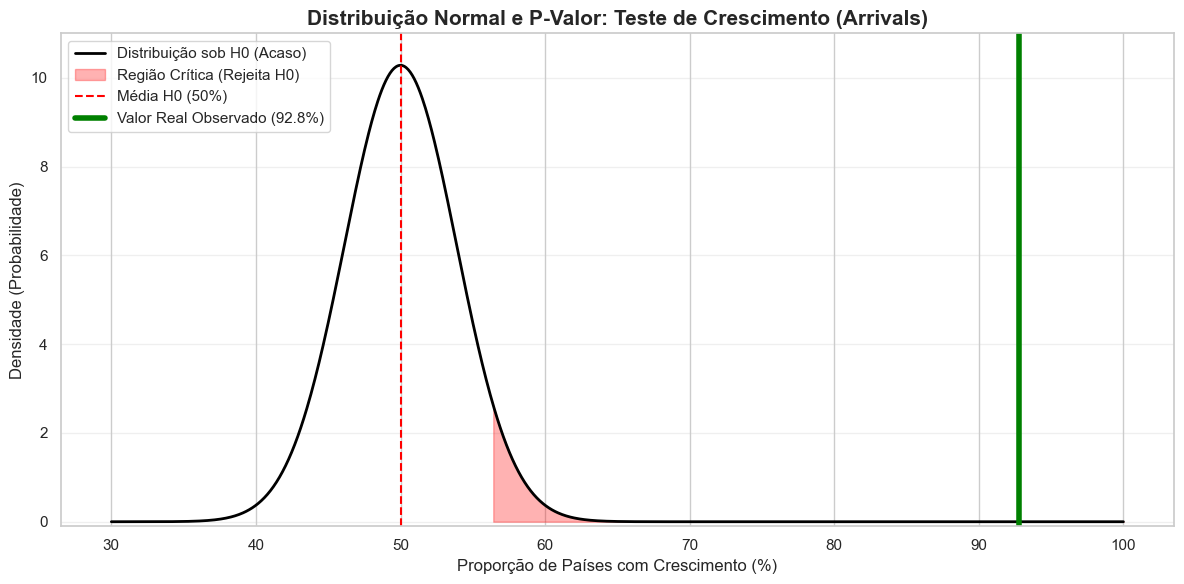

In [302]:
n_paises = 166
p_h0 = 0.50 # Hipotese nula(equilibrio)
p_obs = 154 / 166 # resultado observado nos gráficos acima

# Calcula a média e o desvio padrão esperado se H0 fosse verdade
media = p_h0
desvio_padrao = np.sqrt((p_h0 * (1 - p_h0)) / n_paises)

# Criando o eixo X (de 30% a 100% para caber tudo)
eixo_x = np.linspace(0.30, 1.0, 1000)
eixo_y = stats.norm.pdf(eixo_x, media, desvio_padrao)


plt.figure(figsize=(12, 6))
plt.plot(eixo_x * 100, eixo_y, color='black', linewidth=2, label='Distribuição sob H0 (Acaso)')
limite_critico = stats.norm.ppf(0.95, media, desvio_padrao) #limite rejeição
plt.fill_between(eixo_x * 100, eixo_y, where=(eixo_x > limite_critico), color='red', alpha=0.3, label='Região Crítica (Rejeita H0)')
plt.axvline(media * 100, color='red', linestyle='--', label=f'Média H0 (50%)') #centro
plt.ylim(-0.1,11)

# Pvalor observado
plt.axvline(p_obs * 100, color='green', linewidth=4, label=f'Valor Real Observado ({p_obs*100:.1f}%)')

plt.title('Distribuição Normal e P-Valor: Teste de Crescimento (Arrivals)', fontsize=15, fontweight='bold')
plt.xlabel('Proporção de Países com Crescimento (%)')
plt.ylabel('Densidade (Probabilidade)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

C:\Users\marco\AppData\Local\Temp\ipykernel_29204\1864607559.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_graficos['Variável'], rotation=15)


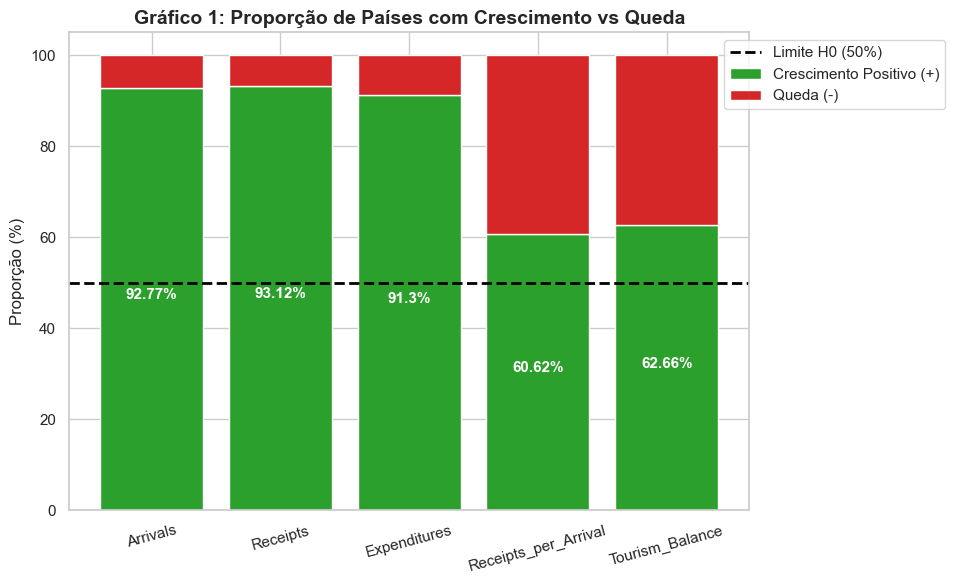

C:\Users\marco\AppData\Local\Temp\ipykernel_29204\1864607559.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(df_graficos['Variável'], rotation=15)


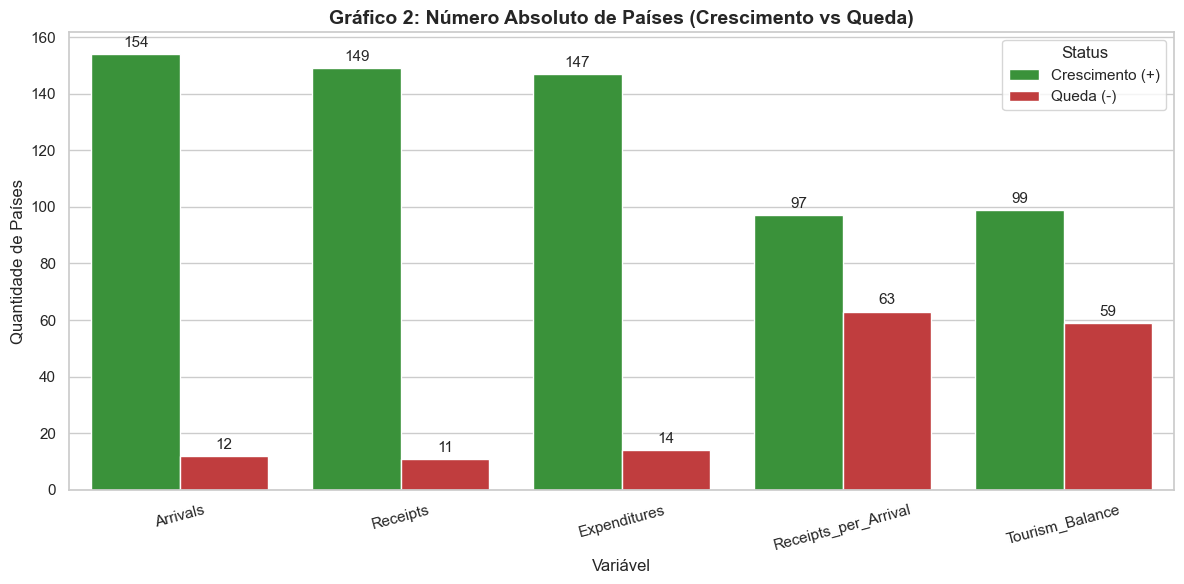

In [289]:
dados = pd.DataFrame({
    'Variável': df_relatorio['Variável'],
    'Total (N)': df_relatorio['Total Países (N)'],
    'Crescimento (+)': df_relatorio['Qtd Crescimento (+)'],
    'Queda (-)': df_relatorio['Qtd Queda (-)'],
    'Prop_Cresc (%)': df_relatorio['Prop Crescimento (+)'].str.replace('%', '').astype(float),
    'Prop_Queda (%)': df_relatorio['Prop Queda (-)'].str.replace('%', '').astype(float)
})

df_graficos = pd.DataFrame(dados)

# gráfico de proporção de crescimento
fig1, ax1 = plt.subplots(figsize=(10, 6))

# queda em cima crescimento em baixo
ax1.bar(df_graficos['Variável'], df_graficos['Prop_Cresc (%)'], label='Crescimento Positivo (+)', color='#2ca02c')
ax1.bar(df_graficos['Variável'], df_graficos['Prop_Queda (%)'], bottom=df_graficos['Prop_Cresc (%)'], label='Queda (-)', color='#d62728')

ax1.set_title('Gráfico 1: Proporção de Países com Crescimento vs Queda', fontsize=14, fontweight='bold')
ax1.set_ylabel('Proporção (%)')
ax1.set_xticklabels(df_graficos['Variável'], rotation=15)
ax1.axhline(50, color='black', linestyle='--', linewidth=2, label='Limite H0 (50%)')
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

# Adicionando os rótulos de % dentro das barras verdes
for i, val in enumerate(df_graficos['Prop_Cresc (%)']):
    ax1.text(i, val / 2, f'{val}%', ha='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

#gráfico da quantidade absoluta de países em queda e crescimento
fig2, ax2 = plt.subplots(figsize=(12, 6))

df_melt = df_graficos.melt(id_vars='Variável', value_vars=['Crescimento (+)', 'Queda (-)'], 
                           var_name='Status', value_name='Nº de Países')

sns.barplot(data=df_melt, x='Variável', y='Nº de Países', hue='Status', palette=['#2ca02c', '#d62728'], ax=ax2)

ax2.set_title('Gráfico 2: Número Absoluto de Países (Crescimento vs Queda)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Quantidade de Países')
ax2.set_xticklabels(df_graficos['Variável'], rotation=15)

# Adicionando os rótulos de dados em cima das barras
for container in ax2.containers:
    ax2.bar_label(container, fontsize=11, padding=3)

plt.tight_layout()
plt.show()

Na base imputada obtemos exatamente o mesmo resultado nos gráficos acima, o que torna a análise mais robusta.

Os resultados permitiram rejeitar H0 para todas as variáveis analisadas, indicando que o crescimento observado não pode ser explicado pelo acaso. A grande maioria dos países apresentaram aumento positivo nas métricas, evidenciando uma expansão global consistente da atividade turística.

Entretanto, ao analisar a eficiência econômica do setor, os resultados foram mais modestos. Embora H0 também tenha sido rejeitada para Receita por Turista (Receipts per Arrival) e Balança Turística (Tourism Balance), apenas cerca de 60% dos países apresentaram crescimento nessas métricas. Isso indica que, apesar da expansão global do turismo e receitas, os ganhos econômicos gerados por esse crescimento não foram distribuídos de forma uniforme entre os países.

#### 1.4. Intervalos de confiança

Nesta etapa, analisamos o crescimento médio anual das principais métricas do turismo mundial e calculamos intervalos de confiança de 95% para verificar se esse crescimento se mantém consistente ao longo do período estudado.

In [290]:
variaveis = ['Arrivals', 'Receipts', 'Expenditures']
resultados_ic = []

for var in variaveis:
    df_var = df.dropna(subset=['Ano', var])
    crescimentos = []
    
    # Agrupando por país para calcular a Taxa Média Anual de Crescimento (CAGR)
    for pais, dados_pais in df_var.groupby('País'):
        dados_pais = dados_pais.sort_values('Ano')
        
        # Precisamos de pelo menos 2 anos para calcular crescimento
        if len(dados_pais) > 1:
            ano_ini = dados_pais['Ano'].min()
            ano_fim = dados_pais['Ano'].max()
            val_ini = dados_pais.iloc[0][var]
            val_fim = dados_pais.iloc[-1][var]
            
            # Evitar divisão por zero
            if val_ini > 0 and ano_fim > ano_ini:
                # CAGR: (Valor Final / Valor Inicial) ^ (1 / Anos) - 1
                cagr = ((val_fim / val_ini) ** (1 / (ano_fim - ano_ini))) - 1
                crescimentos.append(cagr * 100) # Multiplica por 100 para ficar em porcentagem
                
    # Intervalo de Confiança (95%)
    crescimentos = np.array(crescimentos)
    media_crescimento = np.mean(crescimentos)
    
    # Margem de erro
    n = len(crescimentos)
    erro_padrao = stats.sem(crescimentos)
    
    # Gerando os limites usando a distribuição t-Student
    ic_inf, ic_sup = stats.t.interval(0.95, df=n-1, loc=media_crescimento, scale=erro_padrao)
    
    consistente = "Sim (IC > 0)" if ic_inf > 0 else "Não (Cruza Zero)"
    
    resultados_ic.append({
        'Variável': var,
        'Crescimento Médio Anual (%)': media_crescimento,
        'IC 95% Inferior (%)': ic_inf,
        'IC 95% Superior (%)': ic_sup,
        'Crescimento Consistente?': consistente
    })

df_ic = pd.DataFrame(resultados_ic)
print("===================================== TABELA DE INTERVALOS DE CONFIANÇA =====================================")
print(df_ic.round(2).to_string(index=False))

===================================== TABELA DE INTERVALOS DE CONFIANÇA =====================================
    Variável  Crescimento Médio Anual (%)  IC 95% Inferior (%)  IC 95% Superior (%) Crescimento Consistente?
    Arrivals                         6.33                 5.44                 7.22             Sim (IC > 0)
    Receipts                         8.49                 7.40                 9.57             Sim (IC > 0)
Expenditures                         7.29                 6.08                 8.50             Sim (IC > 0)


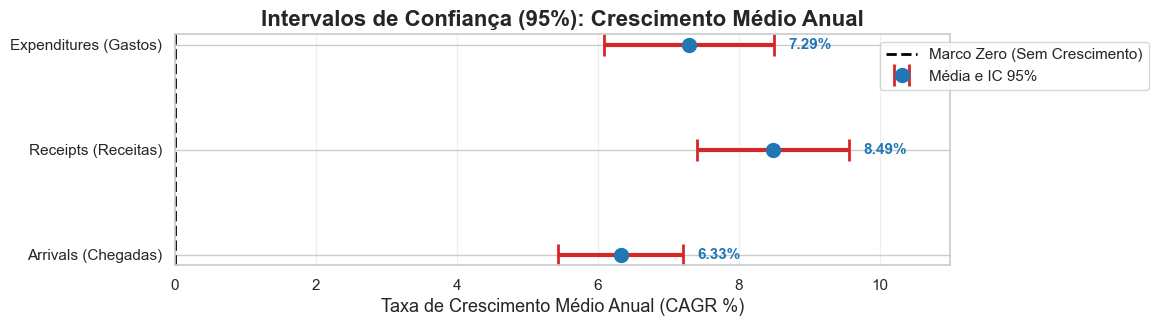

In [291]:
variaveis = ['Arrivals (Chegadas)', 'Receipts (Receitas)', 'Expenditures (Gastos)']
medias = df_ic['Crescimento Médio Anual (%)']
limite_inferior = df_ic['IC 95% Inferior (%)']
limite_superior = df_ic['IC 95% Superior (%)']

# distancia media dos limites
erro_inferior = np.array(medias) - np.array(limite_inferior)
erro_superior = np.array(limite_superior) - np.array(medias)
erros = [erro_inferior, erro_superior]

fig, ax = plt.subplots(figsize=(10, 3))
ax.errorbar(medias, variaveis, xerr=erros, fmt='o', color='#1f77b4', 
            ecolor='#d62728', elinewidth=3, capsize=8, capthick=2, markersize=10, 
            label='Média e IC 95%')

# linha do 0
ax.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Marco Zero (Sem Crescimento)')

for i, media in enumerate(medias):
    ax.text(limite_superior[i] + 0.2, i, f'{media:.2f}%', ha='left', va='center', fontweight='bold', color='#1f77b4', fontsize=11)

# Formatação visual (ajustes de fonte e estilo)
ax.set_title('Intervalos de Confiança (95%): Crescimento Médio Anual', fontsize=16, fontweight='bold')
ax.set_xlabel('Taxa de Crescimento Médio Anual (CAGR %)', fontsize=13)
ax.set_xlim(0, 11)
ax.grid(axis='x', alpha=0.3)
ax.legend(['Média e IC 95%', 'Marco Zero (Sem Crescimento)'], loc='lower right')

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(bbox_to_anchor=(0.9, 1), loc='upper left')
#plt.tight_layout() # Garante que nada saia da borda
plt.show()

Os resultados mostram que o setor de turismo se expandiu de maneira consistente durante o período em questão. As receitas (Receipts) lideraram com um crescimento médio anual de 8,49%, enquanto os gastos com viagens internacionais (Expenditures) aumentaram em 7,29% ao ano. O número de chegadas de turistas (Arrivals) também cresceu significativamente, com uma média de 6,33% por ano. Ademais, todos os intervalos de confiança ficaram acima de zero, o que indica que esse aumento foi consistente e não o resultado de variações aleatórias nos dados. Um aspecto crucial é que o aumento das receitas superou o crescimento do número de turistas, indicando que o setor não apenas atraiu mais visitantes, mas também foi capaz de criar mais valor econômico com essa expansão. 

#### 1.5. Simulações por Bootstrap

Veremos como o turismo se comporta com uma simulação com bootstrap com 10000 repetições. A cada repetição calculamos a taxa média de crescimento.

    Variável  Observado (%)  Média Boot (%)  Mediana Boot (%)  Desvio Padrão  IC 95% Inf (%)  IC 95% Sup (%)  Simulações <= 0 (%)
    Arrivals           6.33            6.32              6.32           0.45            5.46            7.23                 0.00
    Receipts           8.49            8.48              8.48           0.55            7.42            9.58                 0.00
Expenditures           7.29            7.30              7.29           0.61            6.13            8.54                 0.00


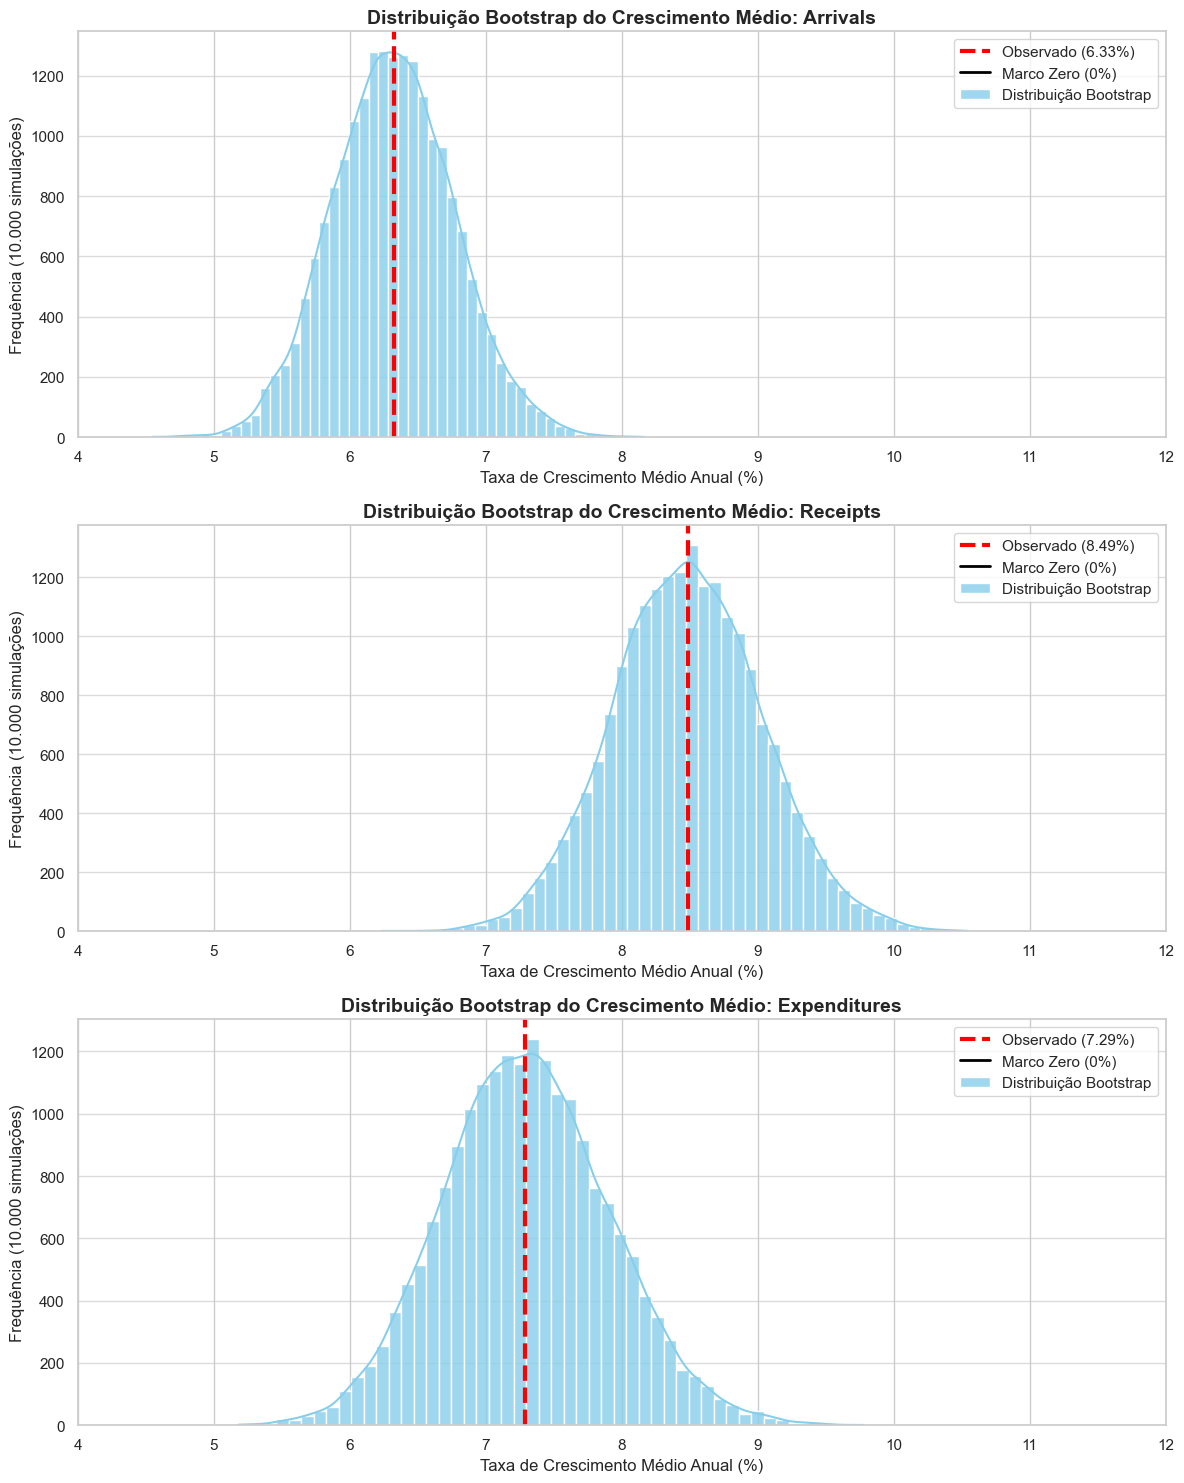

In [304]:
# Calculamos o crescimento (CAGR) por país
def calcular_cagr_por_pais(df, variavel):
    df_var = df.dropna(subset=['Ano', variavel])
    crescimentos = []
    
    for pais, dados_pais in df_var.groupby('País'):
        dados_pais = dados_pais.sort_values('Ano')
        if len(dados_pais) > 1:
            ano_ini = dados_pais['Ano'].min()
            ano_fim = dados_pais['Ano'].max()
            val_ini = dados_pais.iloc[0][variavel]
            val_fim = dados_pais.iloc[-1][variavel]
            
            if val_ini > 0 and ano_fim > ano_ini:
                cagr = ((val_fim / val_ini) ** (1 / (ano_fim - ano_ini))) - 1
                crescimentos.append(cagr * 100)
    return np.array(crescimentos)

variaveis = ['Arrivals', 'Receipts', 'Expenditures']
simulacoes = 20000
np.random.seed(42)
resultados_bootstrap = []

fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# loop para cada variavel
for idx, var in enumerate(variaveis):
    # Pega os dados reais
    dados_cagr = calcular_cagr_por_pais(df, var)
    crescimento_observado = np.mean(dados_cagr)
    
    # Realiza o Bootstrap (Sorteio com reposição 10.000 vezes)
    medias_simuladas = []
    n_paises = len(dados_cagr)
    
    for _ in range(simulacoes):
        amostra = np.random.choice(dados_cagr, size=n_paises, replace=True)
        medias_simuladas.append(np.mean(amostra))
        
    medias_simuladas = np.array(medias_simuladas)
    
    media_boot = np.mean(medias_simuladas)
    mediana_boot = np.median(medias_simuladas)
    desvio_boot = np.std(medias_simuladas)
    ic_inf = np.percentile(medias_simuladas, 2.5) # Limite inferior 95%
    ic_sup = np.percentile(medias_simuladas, 97.5) # Limite superior 95%
    prop_menor_zero = np.mean(medias_simuladas <= 0) * 100
    
    # Guarda os resultados para a tabela
    resultados_bootstrap.append({
        'Variável': var,
        'Observado (%)': crescimento_observado,
        'Média Boot (%)': media_boot,
        'Mediana Boot (%)': mediana_boot,
        'Desvio Padrão': desvio_boot,
        'IC 95% Inf (%)': ic_inf,
        'IC 95% Sup (%)': ic_sup,
        'Simulações <= 0 (%)': prop_menor_zero
    })
    
    # histograma
    ax = axes[idx]
    sns.histplot(medias_simuladas, bins=50, kde=True, color='skyblue', alpha=0.8, ax=ax, label='Distribuição Bootstrap')
    
    # valor observado
    ax.axvline(crescimento_observado, color='red', linestyle='--', linewidth=3, label=f'Observado ({crescimento_observado:.2f}%)')
    #ax.axvline(media_boot, color='red', linestyle=':', linewidth=3, label=f'Bootstrap ({media_boot:.2f}%)')

    ax.axvline(0, color='black', linestyle='-', linewidth=2, label='Marco Zero (0%)')
    ax.set_xlim(4, 12)
    ax.set_title(f'Distribuição Bootstrap do Crescimento Médio: {var}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Taxa de Crescimento Médio Anual (%)')
    ax.set_ylabel('Frequência (10.000 simulações)')
    ax.legend()
    ax.grid(axis='y', alpha=0.7)


df_resultados = pd.DataFrame(resultados_bootstrap)
print(df_resultados.round(4).to_string(index=False))

plt.tight_layout()
plt.show()

Os resultados do Bootstrap sustentam que o crescimento do turismo mundial foi sólido e não se baseia em alguns poucos países que se destacam.  Os resultados das simulações foram bastante alinhados aos valores observados, o que sugere que o crescimento é representativo do grupo de países analisados. Simplesmente não houve nenhuma simulação das 10.000 rodadas que mostrasse crescimento igual ou inferior a zero, o que indica um risco praticamente inexistente de estagnação ou contração. Os intervalos de confiança, que permaneceram inteiramente acima de zero, indicam que o aumento das chegadas, das receitas e dos gastos dos turistas foi sólido e não dependente da composição específica da amostra.

### 2. Conclusão

*A partir das análises descritivas, dos testes de hipóteses e das simulações efetuadas, surgem as seguintes conclusões:*

**1. O turismo aumentou ou diminuiu no período em questão?**
O turismo internacional aumentou de forma expresiva durante o período de 2004 a 2018.

**2. Esse crescimento aparece em chegadas, receitas e gastos?** Sim. O crescimento principais variáveis. O teste binomial confirmou que mais de 90% dos países possuem crescimento positivo em arrivals, expenditures e receipts. Em termos de média composta de longo prazo (CAGR), as receitas lideraram o avanço com uma taxa média de 8,49% ao ano, seguidas pelos gastos  com 7,29% ao ano e pelo volume físico de chegadas com 6,33% ao ano.

**3. Houve anos de queda ou comportamento anormal?** Sim. O setor apresentou sensibilidade a choques de curto prazo, apresentando um comportamento anormal devido a crise de 2009, onde todas as métricas sofreram uma retração considerável. Entretando, apresentou uma recuperação rápida.

**4. A conclusão muda quando usamos a base original em vez da imputada?** Não. A têndencia de crescimento é forte em ambos os dados.

**5. A imputação afetou muito os resultados?** Não. Apesar de pequenas variações em algumas métricas onde havia muitos dados faltantes, a imputação não alterou o resultado significativamente. Usando qualquer uma das bases teríamos o mesmo resultado final.

**6. O crescimento parece robusto ou depende de poucos países?** O crescimento é robusto e bem distribuído globalmente, não dependendo do desempenho isolado de poucos países grandes (outliers). O teste de estresse via simulação de Bootstrap com 10.000 iterações provou que mesmo alterando aleatoriamente a composição da amostra de nações, a taxa média global permaneceu estável e em nenhuma das simulações o crescimento foi menor ou igual a zero.